In [35]:

# EMPLOYEE ATTRITION PREDICTION USING MACHINE LEARNING
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

sns.set_style("whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [36]:
# ==========================
# LOAD DATASET
# ==========================

df = pd.read_csv("HR_Attrition.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [37]:
# ==========================
# DISPLAY FIRST 10 ROWS
# ==========================

df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [38]:
# ==========================
# DATASET SHAPE
# ==========================

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1470
Columns : 35


In [39]:
# ==========================
# COLUMN NAMES
# ==========================

df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [40]:
# ==========================
# DATASET INFORMATION
# ==========================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [41]:
# ==========================
# SUMMARY STATISTICS
# ==========================

df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [42]:
# ==========================
# TARGET COLUMN
# ==========================

df["Attrition"].value_counts()


Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [43]:
# ==========================
# ATTRITION RATE
# ==========================

attrition_rate = df["Attrition"].value_counts(normalize=True)*100

print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [44]:
# ==========================
# NUMERIC COLUMNS
# ==========================

numeric_columns = df.select_dtypes(include=np.number).columns

print("Numeric Columns :",len(numeric_columns))

numeric_columns

Numeric Columns : 26


Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [45]:
# ==========================
# CATEGORICAL COLUMNS
# ==========================

categorical_columns = df.select_dtypes(exclude=np.number).columns

print("Categorical Columns :",len(categorical_columns))

categorical_columns

Categorical Columns : 9


Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [46]:
# ==========================
# CHECK MISSING VALUES
# ==========================

missing = df.isnull().sum()

print(missing)

print("\nTotal Missing Values :",missing.sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [47]:
# ==========================
# DROP UNNECESSARY COLUMNS
# ==========================

drop_columns = [

    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"

]

df.drop(columns=drop_columns,inplace=True)

df.shape

(1470, 31)

In [48]:
# ==========================
# ENCODE TARGET COLUMN
# ==========================

df["Attrition"] = df["Attrition"].map({

    "Yes":1,
    "No":0

})

df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [49]:
# ==========================
# SPLIT FEATURES & TARGET
# ==========================

X = df.drop("Attrition",axis=1)

y = df["Attrition"]

print(X.shape)

print(y.shape)

(1470, 30)
(1470,)


In [50]:
# ==========================
# IDENTIFY NUMERIC &
# CATEGORICAL FEATURES
# ==========================

numeric_columns = X.select_dtypes(include=["int64","float64"]).columns

categorical_columns = X.select_dtypes(include=["object"]).columns

print("Numeric :",len(numeric_columns))

print("Categorical :",len(categorical_columns))

Numeric : 23
Categorical : 7


In [51]:
# ==========================
# PREPROCESSING PIPELINE
# ==========================

preprocessor = ColumnTransformer(

    transformers=[

        ("num",

         StandardScaler(),

         numeric_columns),

        ("cat",

         OneHotEncoder(handle_unknown="ignore"),

         categorical_columns)

    ]

)

print("Preprocessing Pipeline Created Successfully")

Preprocessing Pipeline Created Successfully


In [52]:
# ==========================
# VERIFY DATASET
# ==========================

print(df.head())

print(df.info())

   Age  Attrition     BusinessTravel  DailyRate              Department  \
0   41          1      Travel_Rarely       1102                   Sales   
1   49          0  Travel_Frequently        279  Research & Development   
2   37          1      Travel_Rarely       1373  Research & Development   
3   33          0  Travel_Frequently       1392  Research & Development   
4   27          0      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EnvironmentSatisfaction  \
0                 1          2  Life Sciences                        2   
1                 8          1  Life Sciences                        3   
2                 2          2          Other                        4   
3                 3          4  Life Sciences                        4   
4                 2          1        Medical                        1   

   Gender  ...  PerformanceRating  RelationshipSatisfaction  StockOptionLevel  \
0  Female  ...         

In [55]:

# TASK 3 - EXPLORATORY DATA ANALYSIS (EDA)

import os

# Create folder to save charts
os.makedirs("charts", exist_ok=True)

Attrition                       0          1
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803


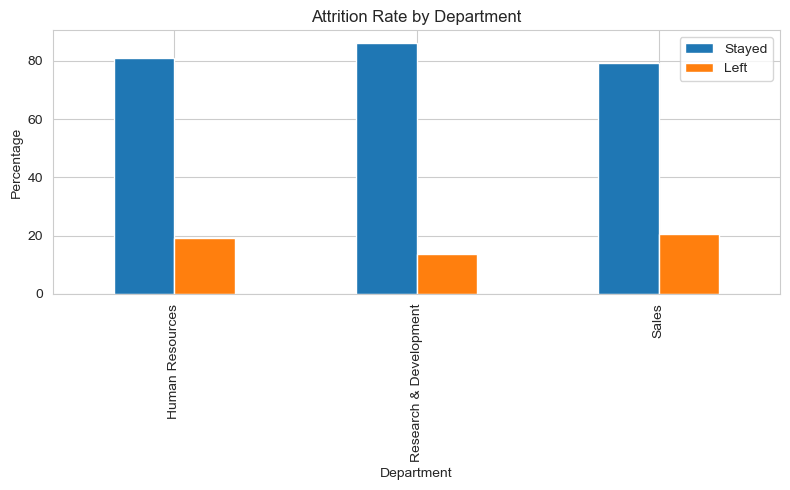

In [56]:
# ==========================================================
# ATTRITION BY DEPARTMENT
# ==========================================================

department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

print(department_attrition)

department_attrition.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Attrition Rate by Department")
plt.ylabel("Percentage")
plt.xlabel("Department")
plt.legend(["Stayed","Left"])

plt.tight_layout()

plt.savefig("charts/chart1_department.png")

plt.show()

Attrition                          0          1
JobRole                                        
Healthcare Representative  93.129771   6.870229
Human Resources            76.923077  23.076923
Laboratory Technician      76.061776  23.938224
Manager                    95.098039   4.901961
Manufacturing Director     93.103448   6.896552
Research Director          97.500000   2.500000
Research Scientist         83.904110  16.095890
Sales Executive            82.515337  17.484663
Sales Representative       60.240964  39.759036


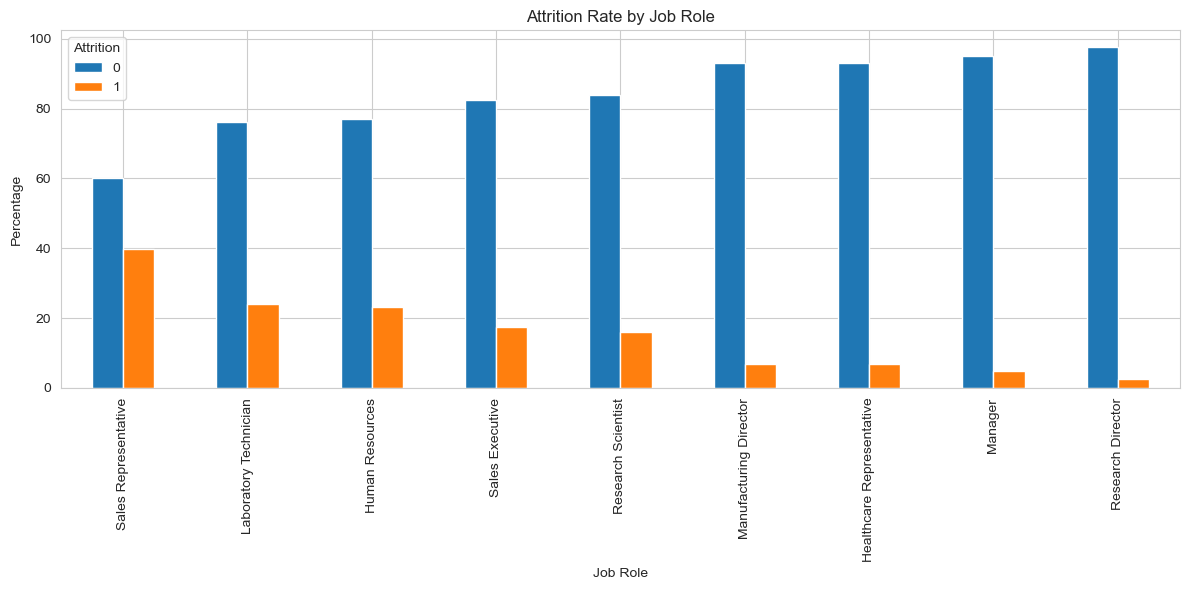

In [57]:
# ==========================================================
# ATTRITION BY JOB ROLE
# ==========================================================

jobrole_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

print(jobrole_attrition)

jobrole_attrition.sort_values(
    by=1,
    ascending=False
).plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Attrition Rate by Job Role")
plt.ylabel("Percentage")
plt.xlabel("Job Role")

plt.tight_layout()

plt.savefig("charts/chart2_jobrole.png")

plt.show()

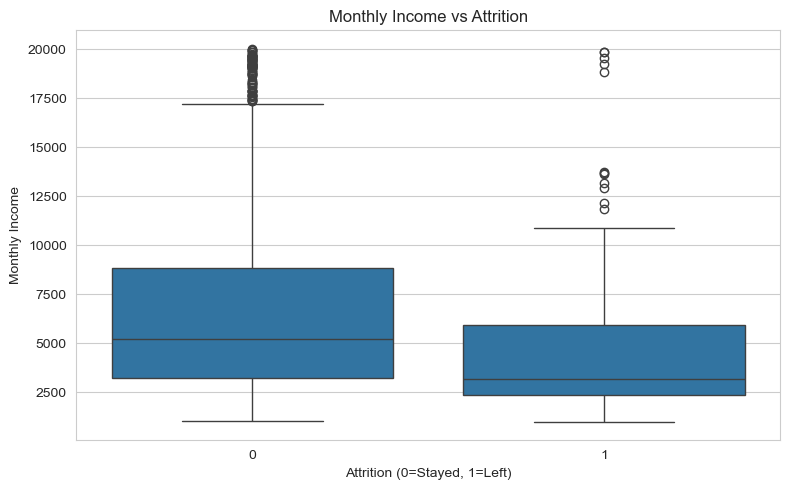

In [58]:
# ==========================================================
# MONTHLY INCOME VS ATTRITION
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition (0=Stayed, 1=Left)")
plt.ylabel("Monthly Income")

plt.tight_layout()

plt.savefig("charts/chart3_income.png")

plt.show()

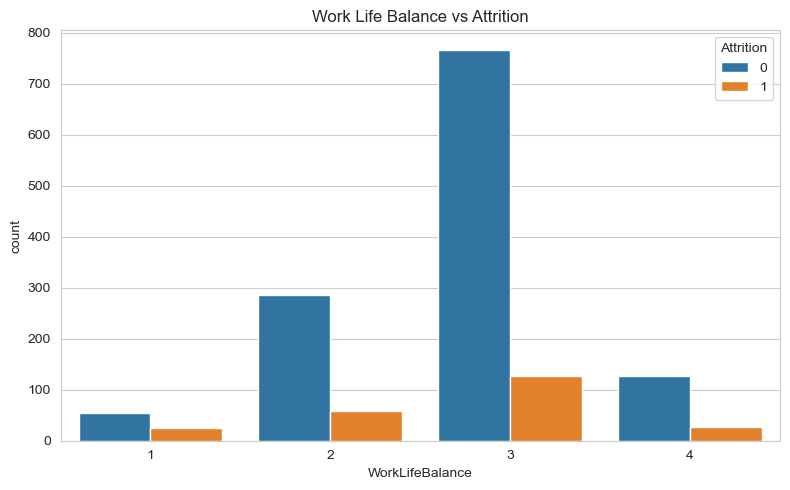

In [59]:
# ==========================================================
# WORK LIFE BALANCE VS ATTRITION
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="WorkLifeBalance",
    hue="Attrition"
)

plt.title("Work Life Balance vs Attrition")

plt.tight_layout()

plt.savefig("charts/chart4_worklife.png")

plt.show()

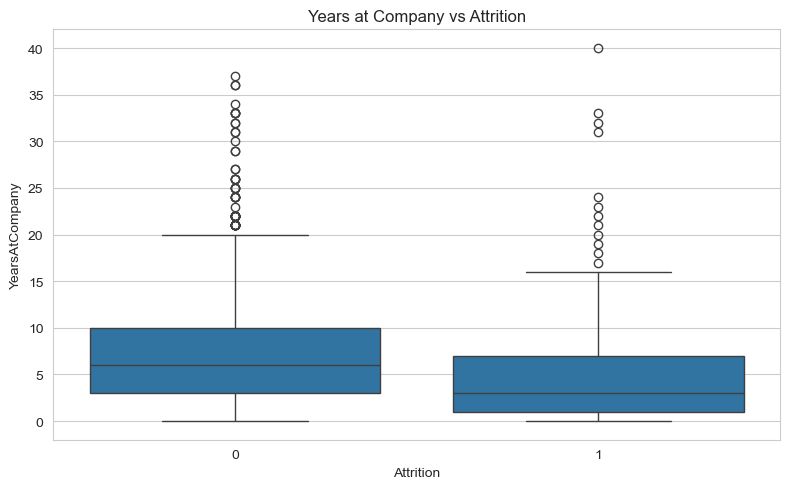

In [60]:
# ==========================================================
# YEARS AT COMPANY VS ATTRITION
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany"
)

plt.title("Years at Company vs Attrition")

plt.tight_layout()

plt.savefig("charts/chart5_years.png")

plt.show()

In [61]:
# ==========================================================
# BUSINESS INSIGHTS
# ==========================================================

print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

print("\n1. Department-wise Attrition (%)")
print(department_attrition[1].sort_values(ascending=False))

print("\n2. Top 5 Job Roles with Highest Attrition (%)")
print(jobrole_attrition[1].sort_values(ascending=False).head())

print("\n3. Average Monthly Income")
print(df.groupby("Attrition")["MonthlyIncome"].mean())

print("\n4. Average Work-Life Balance")
print(df.groupby("Attrition")["WorkLifeBalance"].mean())

print("\n5. Average Years at Company")
print(df.groupby("Attrition")["YearsAtCompany"].mean())

BUSINESS INSIGHTS

1. Department-wise Attrition (%)
Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: 1, dtype: float64

2. Top 5 Job Roles with Highest Attrition (%)
JobRole
Sales Representative     39.759036
Laboratory Technician    23.938224
Human Resources          23.076923
Sales Executive          17.484663
Research Scientist       16.095890
Name: 1, dtype: float64

3. Average Monthly Income
Attrition
0    6832.739659
1    4787.092827
Name: MonthlyIncome, dtype: float64

4. Average Work-Life Balance
Attrition
0    2.781022
1    2.658228
Name: WorkLifeBalance, dtype: float64

5. Average Years at Company
Attrition
0    7.369019
1    5.130802
Name: YearsAtCompany, dtype: float64


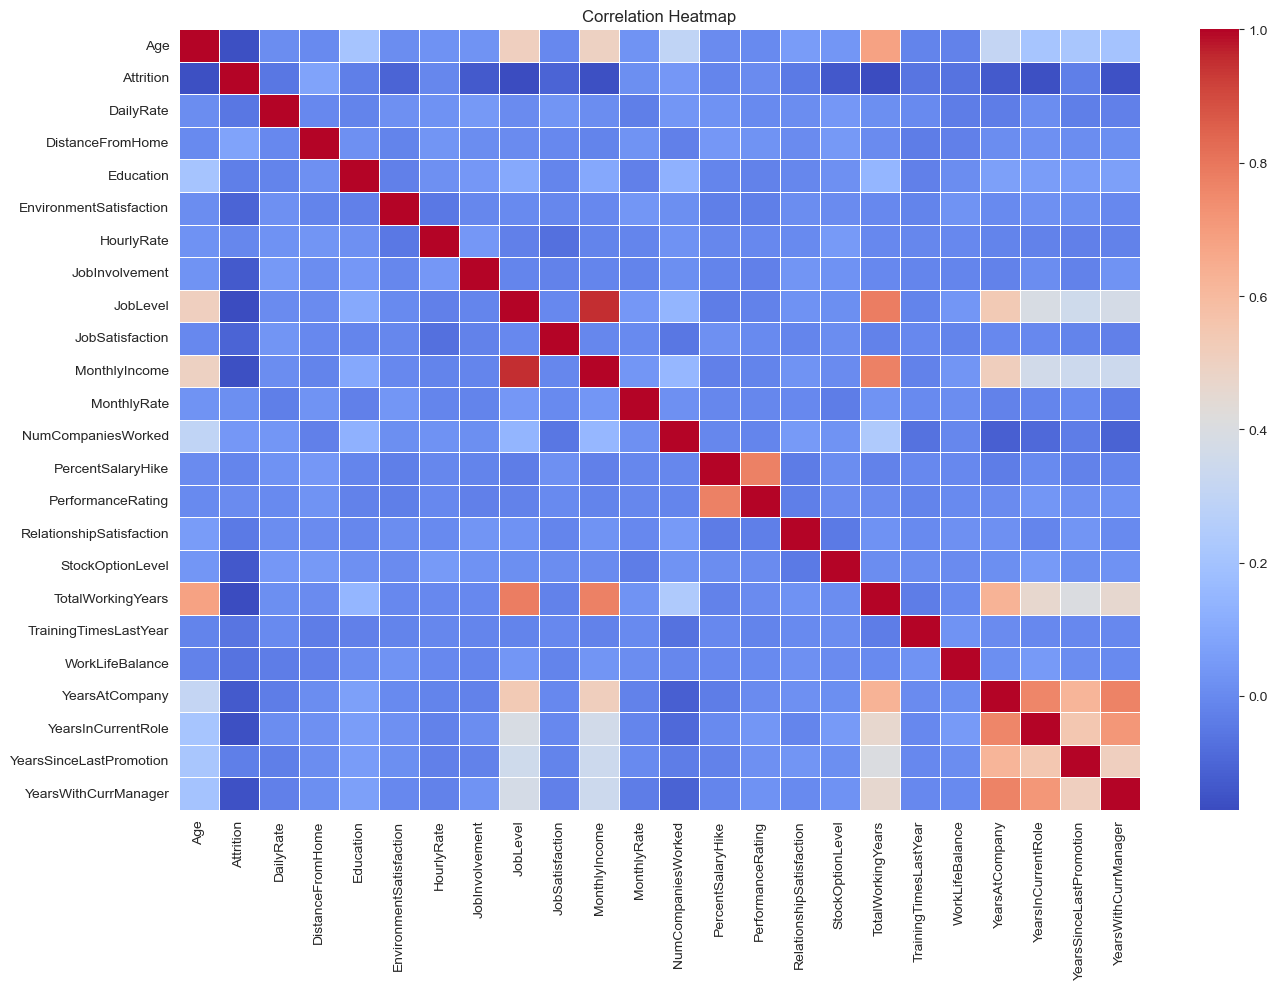

In [62]:
# ==========================================================
#  CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("charts/chart6_correlation.png")

plt.show()

In [63]:
# ==========================================================
# SPLIT DATASET
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (1176, 30)
Testing Shape : (294, 30)


In [64]:
# ==========================================================
# LOGISTIC REGRESSION
# ==========================================================

log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_model.fit(X_train, y_train)

print("Logistic Regression Trained")

Logistic Regression Trained


In [65]:
# ==========================================================
# RANDOM FOREST
# ==========================================================

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

print("Random Forest Trained")

Random Forest Trained


In [66]:
# ==========================================================
# GRADIENT BOOSTING
# ==========================================================

gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

print("Gradient Boosting Trained")

Gradient Boosting Trained


In [67]:
# ==========================================================
# MAKE PREDICTIONS
# ==========================================================

log_pred = log_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

log_prob = log_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
gb_prob = gb_model.predict_proba(X_test)[:, 1]

print("Predictions Completed")

Predictions Completed


In [68]:
# ==========================================================
# MODEL COMPARISON TABLE
# ==========================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Precision":[
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],

    "Recall":[
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],

    "F1 Score":[
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],

    "ROC AUC":[
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]

})

comparison = comparison.sort_values(
    by="ROC AUC",
    ascending=False
)

comparison

,Model,Precision,Recall,F1 Score,ROC AUC
2,Gradient Boosting,0.714286,0.212766,0.327869,0.805065
0,Logistic Regression,0.348837,0.638298,0.451128,0.803170
1,Random Forest,0.625000,0.106383,0.181818,0.783185


In [69]:
# ==========================================================
# BEST MODEL
# ==========================================================

best_model = comparison.iloc[0]["Model"]

print("Best Model :", best_model)

Best Model : Gradient Boosting


In [70]:
# ==========================================================
# CONFUSION MATRIX (BEST MODEL = RANDOM FOREST ASSUMED)
# ==========================================================

from sklearn.metrics import confusion_matrix

rf_pred = rf_model.predict(X_test)

cm = confusion_matrix(y_test, rf_pred)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[244   3]
 [ 42   5]]


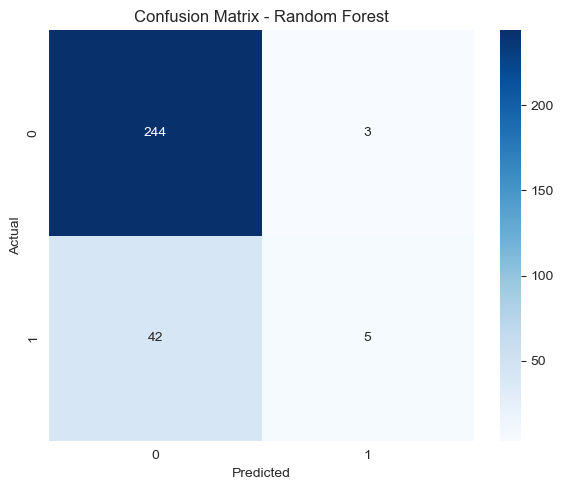

In [71]:
# ==========================================================
# CONFUSION MATRIX HEATMAP
# ==========================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("charts/confusion_matrix.png")

plt.show()

In [72]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.62      0.11      0.18        47

    accuracy                           0.85       294
   macro avg       0.74      0.55      0.55       294
weighted avg       0.82      0.85      0.80       294



In [73]:
# ==========================================================
# FEATURE IMPORTANCE (RANDOM FOREST)
# ==========================================================

feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
9,num__MonthlyIncome,0.069310
0,num__Age,0.060438
16,num__TotalWorkingYears,0.055554
1,num__DailyRate,0.049132
19,num__YearsAtCompany,0.046814
2,num__DistanceFromHome,0.044015
5,num__HourlyRate,0.043586
10,num__MonthlyRate,0.042728
11,num__NumCompaniesWorked,0.037213
22,num__YearsWithCurrManager,0.037139


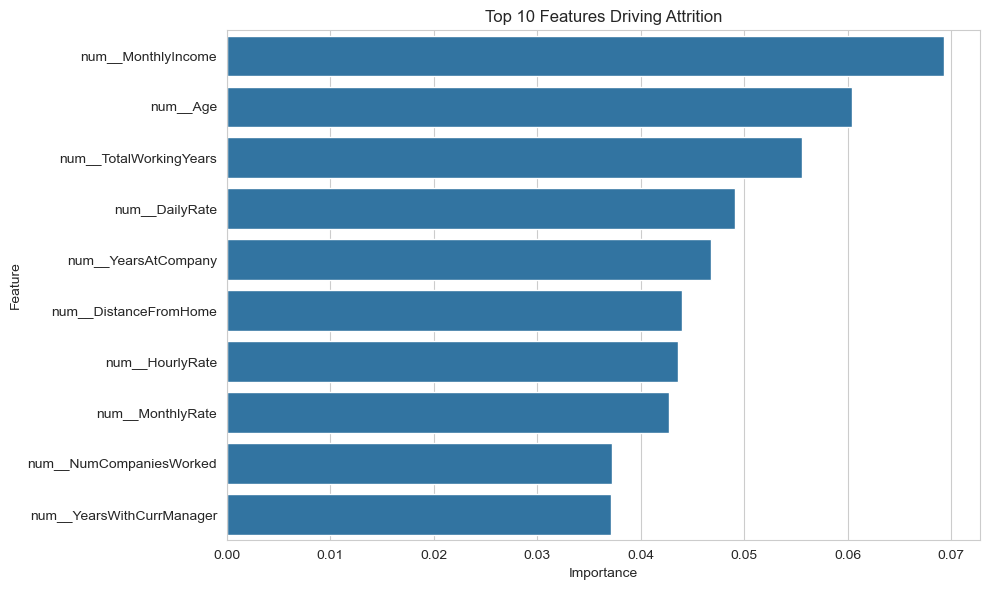

In [74]:
# ==========================================================
# TOP 10 FEATURES PLOT
# ==========================================================

top10 = importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features Driving Attrition")

plt.tight_layout()

plt.savefig("charts/top10_features.png")

plt.show()

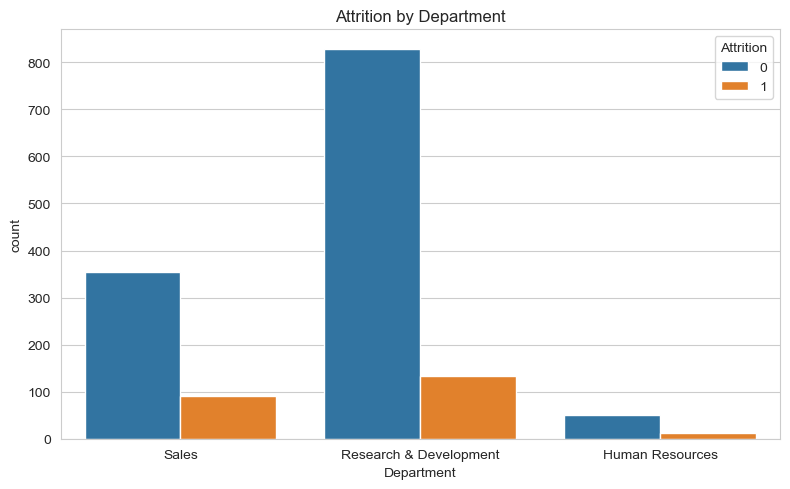

In [76]:
# ==========================================================
# CHART 1 - ATTRITION BY DEPARTMENT
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Department",
    hue="Attrition"
)

plt.title("Attrition by Department")

plt.tight_layout()

plt.savefig("charts/attrition_department.png")

plt.show()

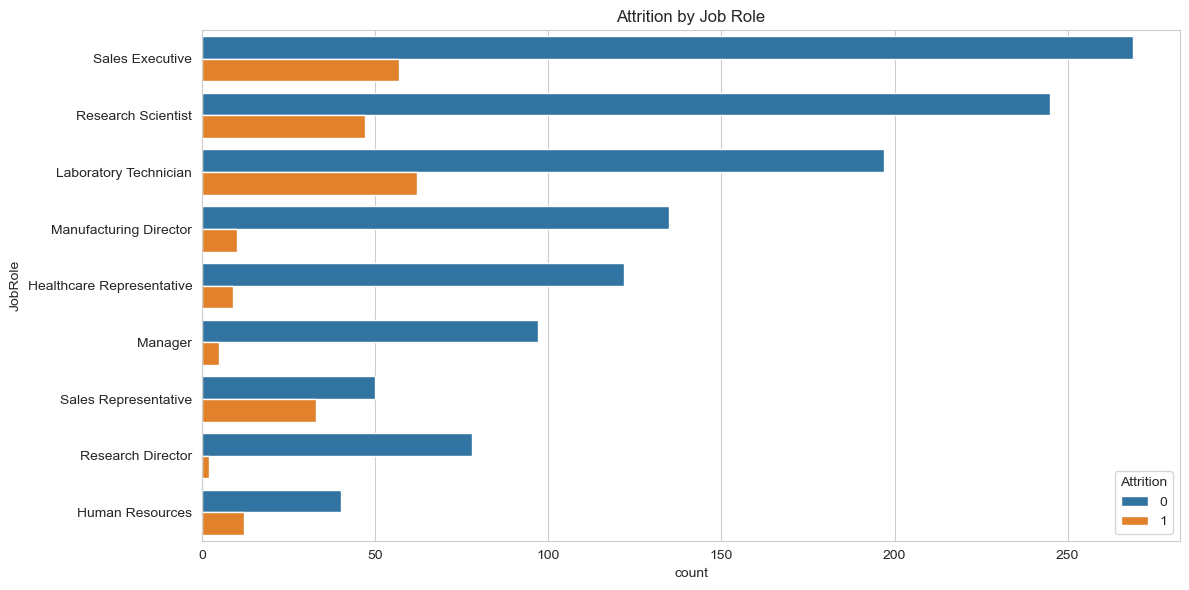

In [77]:
# ==========================================================
# CHART 2 - ATTRITION BY JOB ROLE
# ==========================================================

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="JobRole",
    hue="Attrition",
    order=df["JobRole"].value_counts().index
)

plt.title("Attrition by Job Role")

plt.tight_layout()

plt.savefig("charts/attrition_jobrole.png")

plt.show()

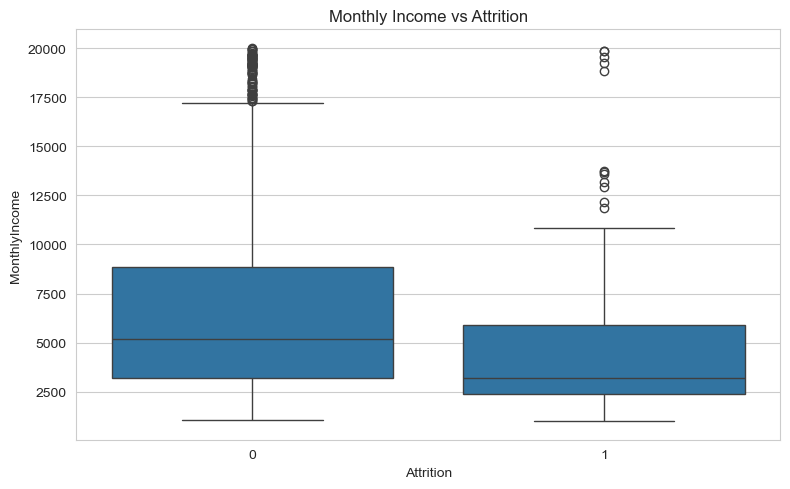

In [78]:
# ==========================================================
# CHART 3 - MONTHLY INCOME VS ATTRITION
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Attrition")

plt.tight_layout()

plt.savefig("charts/income_attrition.png")

plt.show()

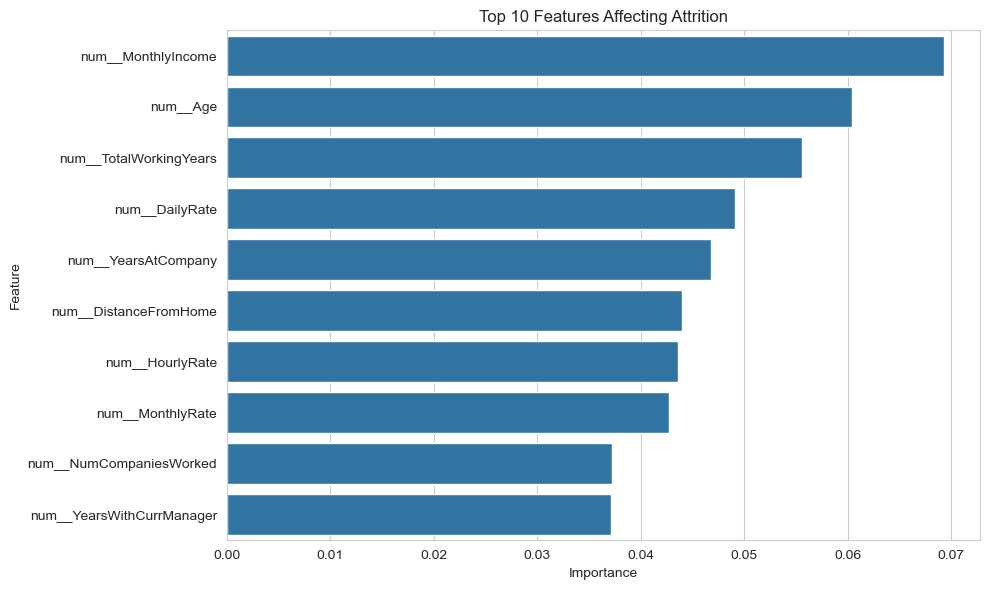

In [80]:
# ==========================================================
# CHART 5 - TOP 10 FEATURE IMPORTANCE
# ==========================================================

top10 = importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features Affecting Attrition")

plt.tight_layout()

plt.savefig("charts/top10_importance.png")

plt.show()

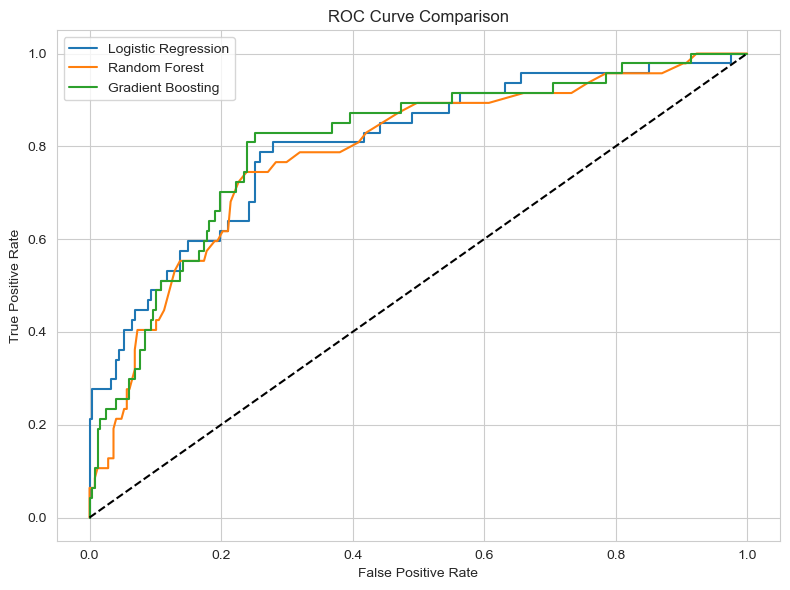

In [81]:
# ==========================================================
# BONUS - ROC CURVE (ALL MODELS)
# ==========================================================

from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

# Logistic Regression
fpr, tpr, _ = roc_curve(y_test, log_prob)
plt.plot(fpr, tpr, label="Logistic Regression")

# Random Forest
fpr, tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr, tpr, label="Random Forest")

# Gradient Boosting
fpr, tpr, _ = roc_curve(y_test, gb_prob)
plt.plot(fpr, tpr, label="Gradient Boosting")

plt.plot([0,1],[0,1],"k--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.tight_layout()

plt.savefig("charts/roc_curve.png")

plt.show()

In [100]:
rf_model.predict(X_test[:5])

array([0, 0, 0, 0, 0])

In [101]:
sample = X_test.iloc[[0]]

pred = rf_model.predict(sample)[0]
prob = rf_model.predict_proba(sample)[0][1]

print("Prediction:", pred)
print("Probability:", prob)

Prediction: 0
Probability: 0.47


In [104]:
template = X.iloc[[0]].copy()

In [105]:
def predict_manual(age, income, years, overtime):

    input_df = X.iloc[[0]].copy()   # safe template row

    input_df["Age"] = age
    input_df["MonthlyIncome"] = income
    input_df["YearsAtCompany"] = years
    input_df["OverTime"] = overtime

    pred = rf_model.predict(input_df)[0]
    prob = rf_model.predict_proba(input_df)[0][1]

    print("\n======================")

    if pred == 1:
        print("⚠ Employee Likely to Leave")
    else:
        print("✅ Employee Likely to Stay")

    print("Probability:", round(prob, 3))
    print("======================\n")

In [106]:
predict_manual(30, 5000, 5, "No")


✅ Employee Likely to Stay
Probability: 0.315



In [108]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# INPUT WIDGETS (FIXED)
age = widgets.IntSlider(value=30, min=18, max=60, description="Age")
income = widgets.IntSlider(value=5000, min=1000, max=20000, description="Income")
years = widgets.IntSlider(value=5, min=0, max=40, description="Years")
overtime = widgets.Dropdown(options=["Yes","No"], value="No", description="OverTime")

display(age, income, years, overtime)

output = widgets.Output()

def predict(_):
    with output:
        clear_output()

        x_input = X.iloc[[0]].copy()

        x_input["Age"] = age.value
        x_input["MonthlyIncome"] = income.value
        x_input["YearsAtCompany"] = years.value
        x_input["OverTime"] = overtime.value

        pred = rf_model.predict(x_input)[0]
        prob = rf_model.predict_proba(x_input)[0][1]

        print("========== RESULT ==========")
        print("⚠ LEAVE" if pred == 1 else "✅ STAY")
        print("Probability:", round(prob, 3))
        print("============================")

btn = widgets.Button(description="Predict", button_style="danger")
btn.on_click(predict)

display(btn, output)

IntSlider(value=30, description='Age', max=60, min=18)

IntSlider(value=5000, description='Income', max=20000, min=1000)

IntSlider(value=5, description='Years', max=40)

Dropdown(description='OverTime', index=1, options=('Yes', 'No'), value='No')

Button(button_style='danger', description='Predict', style=ButtonStyle())

Output()